In [ ]:
!pip install praw vaderSentiment pandas matplotlib requests

In [ ]:
import requests
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import pandas as pd
from datetime import datetime
import time
import matplotlib.pyplot as plt

In [ ]:
analyzer = SentimentIntensityAnalyzer()

SUBREDDITS = ["tinder", "hinge", "bumble", "hingeapp"]

BASE_URL = "https://arctic-shift.photon-reddit.com/api"

def get_posts(subreddit, limit=50):
    posts = []
    try:
        response = requests.get(f"{BASE_URL}/posts/search", params={
            "subreddit": subreddit,
            "limit": limit,
            "sort": "desc"
        })
        data = response.json()
        posts = data.get("data", [])
        print(f"  Got {len(posts)} posts from r/{subreddit}")
    except Exception as e:
        print(f"  Error fetching posts from r/{subreddit}: {e}")
    return posts

def get_comments(post_id):
    comments = []
    try:
        response = requests.get(f"{BASE_URL}/comments/search", params={
            "link_id": f"t3_{post_id}",   # ← fixed: t3_ prefix
            "limit": 100
        })
        data = response.json()
        comments = data.get("data", [])
    except Exception as e:
        print(f"  Error fetching comments for post {post_id}: {e}")
    return comments

data = []

for sub in SUBREDDITS:
    print(f"\nScraping r/{sub}...")
    posts = get_posts(sub, limit=50)

    for post in posts:
        post_id = post.get("id", "")
        post_title = post.get("title", "")
        post_score = post.get("score", 0)
        post_flair = post.get("link_flair_text", "")

        # Skip posts with no comments
        if post.get("num_comments", 0) == 0:
            continue

        comments = get_comments(post_id)

        for comment in comments:
            body = comment.get("body", "")

            if not body or body in ("[deleted]", "[removed]") or len(body.strip()) < 10:
                continue

            scores = analyzer.polarity_scores(body)
            compound = scores["compound"]

            if compound >= 0.05:
                label = "positive"
            elif compound <= -0.05:
                label = "negative"
            else:
                label = "neutral"

            created = comment.get("created_utc", 0)
            try:
                created_str = datetime.utcfromtimestamp(int(created)).strftime("%Y-%m-%d %H:%M")
            except:
                created_str = ""

            data.append({
                "subreddit": sub,
                "post_title": post_title,
                "post_flair": post_flair,
                "post_score": post_score,
                "comment": body,
                "comment_score": comment.get("score", 0),
                "vader_compound": round(compound, 4),
                "vader_positive": round(scores["pos"], 4),
                "vader_negative": round(scores["neg"], 4),
                "vader_neutral": round(scores["neu"], 4),
                "sentiment_label": label,
                "comment_length": len(body),
                "created_utc": created_str,
                "author": comment.get("author", ""),
            })

        time.sleep(0.3)

    count = len([d for d in data if d["subreddit"] == sub])
    print(f"  ✅ Done — {count} comments collected from r/{sub}")

df = pd.DataFrame(data)
print(f"\n✅ Total comments collected: {len(df)}")
df.head()


Scraping r/tinder...
  Got 50 posts from r/tinder


/tmp/ipykernel_1859/1783908054.py:71: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  created_str = datetime.utcfromtimestamp(int(created)).strftime("%Y-%m-%d %H:%M")


  ✅ Done — 465 comments collected from r/tinder

Scraping r/hinge...
  Got 50 posts from r/hinge
  ✅ Done — 40 comments collected from r/hinge

Scraping r/bumble...
  Got 50 posts from r/bumble
  ✅ Done — 466 comments collected from r/bumble

Scraping r/hingeapp...
  Got 50 posts from r/hingeapp
  ✅ Done — 161 comments collected from r/hingeapp

✅ Total comments collected: 1132


,subreddit,post_title,post_flair,post_score,comment,comment_score,vader_compound,vader_positive,vader_negative,vader_neutral,sentiment_label,comment_length,created_utc,author
0,tinder,"Just created a tinder profile, thoughts on pho...",None,1,Hello /u/Party-Western5378! Thank you for your...,1,0.8172,0.165,0.000,0.835,positive,397,2026-05-12 07:26,AutoModerator
1,tinder,Tinder showed me there were 3 people that like...,None,1,Just 3? Tinder isn't for everyone,1,0.0000,0.000,0.000,1.000,neutral,34,2026-05-12 07:16,honesttruth2703
2,tinder,Tinder showed me there were 3 people that like...,None,1,its a BS. \nWhen you dont have subscription th...,1,-0.0772,0.094,0.104,0.803,negative,146,2026-05-12 07:09,OrionJustice
3,tinder,Tinder showed me there were 3 people that like...,None,1,"They're probably not fake, but they are more t...",1,0.5157,0.143,0.000,0.857,positive,170,2026-05-12 06:49,ZesteeTV
4,tinder,Tinder showed me there were 3 people that like...,None,1,"Awww man :(.\n\nNgl, I really feel disappointe...",1,-0.2682,0.125,0.228,0.647,negative,86,2026-05-12 06:46,GASOTO223


In [ ]:
print(f"Total rows in df: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print(df.head())

Total rows in df: 1132
Columns: ['subreddit', 'post_title', 'post_flair', 'post_score', 'comment', 'comment_score', 'vader_compound', 'vader_positive', 'vader_negative', 'vader_neutral', 'sentiment_label', 'comment_length', 'created_utc', 'author']
  subreddit                                         post_title post_flair  \
0    tinder  Just created a tinder profile, thoughts on pho...       None   
1    tinder  Tinder showed me there were 3 people that like...       None   
2    tinder  Tinder showed me there were 3 people that like...       None   
3    tinder  Tinder showed me there were 3 people that like...       None   
4    tinder  Tinder showed me there were 3 people that like...       None   

   post_score                                            comment  \
0           1  Hello /u/Party-Western5378! Thank you for your...   
1           1                 Just 3? Tinder isn't for everyone    
2           1  its a BS. \nWhen you dont have subscription th...   
3           1  T

In [ ]:
print("="*60)
print("SENTIMENT SUMMARY BY SUBREDDIT")
print("="*60)

summary = df.groupby("subreddit").agg(
    total_comments=("comment", "count"),
    avg_compound=("vader_compound", "mean"),
    pct_positive=("sentiment_label", lambda x: (x == "positive").mean() * 100),
    pct_neutral=("sentiment_label", lambda x: (x == "neutral").mean() * 100),
    pct_negative=("sentiment_label", lambda x: (x == "negative").mean() * 100),
).round(2)

print(summary)

SENTIMENT SUMMARY BY SUBREDDIT
           total_comments  avg_compound  pct_positive  pct_neutral  \
subreddit                                                            
bumble                466          0.17         50.64        17.60   
hinge                  40          0.16         42.50        40.00   
hingeapp              161          0.50         77.64        12.42   
tinder                465          0.16         51.40        23.87   

           pct_negative  
subreddit                
bumble            31.76  
hinge             17.50  
hingeapp           9.94  
tinder            24.73  


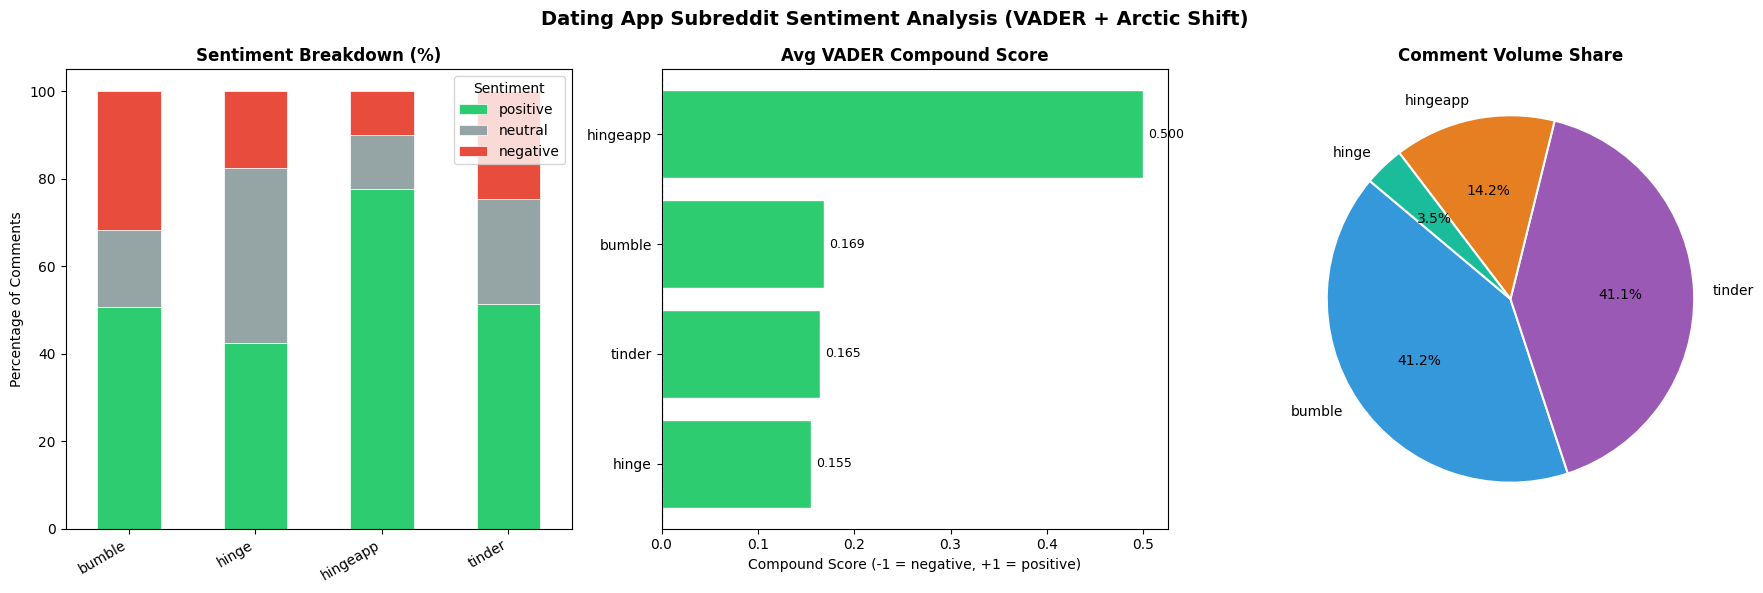

✅ Chart saved!


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Dating App Subreddit Sentiment Analysis (VADER + Arctic Shift)", fontsize=14, fontweight="bold")

colors = {"positive": "#2ecc71", "neutral": "#95a5a6", "negative": "#e74c3c"}

# Plot 1: Stacked bar — sentiment breakdown
breakdown = df.groupby(["subreddit", "sentiment_label"]).size().unstack(fill_value=0)
breakdown_pct = breakdown.div(breakdown.sum(axis=1), axis=0) * 100
for col in ["positive", "neutral", "negative"]:
    if col not in breakdown_pct.columns:
        breakdown_pct[col] = 0
breakdown_pct[["positive", "neutral", "negative"]].plot(
    kind="bar", stacked=True, ax=axes[0],
    color=[colors["positive"], colors["neutral"], colors["negative"]],
    edgecolor="white", linewidth=0.5
)
axes[0].set_title("Sentiment Breakdown (%)", fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Percentage of Comments")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha="right")
axes[0].legend(title="Sentiment", loc="upper right")

# Plot 2: Avg compound score
avg_scores = df.groupby("subreddit")["vader_compound"].mean().sort_values()
bar_colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in avg_scores.values]
axes[1].barh(avg_scores.index, avg_scores.values, color=bar_colors, edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Avg VADER Compound Score", fontweight="bold")
axes[1].set_xlabel("Compound Score (-1 = negative, +1 = positive)")
for i, val in enumerate(avg_scores.values):
    axes[1].text(
        val + 0.005 if val >= 0 else val - 0.005, i,
        f"{val:.3f}", va="center",
        ha="left" if val >= 0 else "right", fontsize=9
    )

# Plot 3: Comment volume pie
counts = df["subreddit"].value_counts()
wedge_colors = ["#3498db", "#9b59b6", "#e67e22", "#1abc9c"]
axes[2].pie(
    counts.values, labels=counts.index, autopct="%1.1f%%",
    colors=wedge_colors[:len(counts)], startangle=140,
    wedgeprops=dict(edgecolor="white", linewidth=1.5)
)
axes[2].set_title("Comment Volume Share", fontweight="bold")

plt.tight_layout()
plt.savefig("dating_app_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved!")

In [ ]:
from google.colab import files

df.to_csv("dating_app_sentiment.csv", index=False)
files.download("dating_app_sentiment.csv")
files.download("dating_app_sentiment.png")
print("✅ Files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Files downloaded!


In [ ]:
from google.colab import files
df.to_csv("dating_app_sentiment.csv", index=False)
files.download("dating_app_sentiment.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#After downloading,the data was cleaned to remove reddits and subreddits not relevant to project manually.